# 📺 YouTube Channel Analyzer & Viewer Insights System

**A beginner-friendly Machine Learning project that:**
- 📈 Predicts video views using **Linear Regression**
- 🏷️ Classifies videos as High/Low performance using **Random Forest**
- 🔵 Groups similar videos using **KMeans Clustering**
- 📊 Visualizes engagement patterns

---

## Step 1: Install & Import Required Libraries

In [1]:
# Install required libraries (run this only once)
# Uncomment the lines below if you get any import errors
# !pip install pandas numpy matplotlib seaborn scikit-learn

# --- Import all required libraries ---
import pandas as pd                          # For data manipulation
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt             # For plotting graphs
import seaborn as sns                        # For beautiful visualizations
import warnings
warnings.filterwarnings('ignore')            # Hide unnecessary warnings

# Machine Learning libraries
from sklearn.linear_model import LinearRegression       # Regression model
from sklearn.ensemble import RandomForestClassifier     # Classification model
from sklearn.cluster import KMeans                      # Clustering model
from sklearn.model_selection import train_test_split    # Split data for training/testing
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler        # Feature scaling

import io                                               # For reading CSV from string

# Set a nice visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Create the Sample Dataset

In [2]:
# --- Create a realistic YouTube dataset as a CSV string ---
# This simulates data you would normally download from YouTube Analytics

csv_data = """title,views,likes,comments,publish_date,duration
Python for Beginners,15200,1400,230,2024-01-05,12
Web Dev Crash Course,8700,920,145,2024-01-12,18
Machine Learning 101,21000,2100,310,2024-01-20,25
Git & GitHub Guide,3400,300,55,2024-01-28,10
Django REST API,6800,700,98,2024-02-03,22
React JS Full Course,19500,1850,280,2024-02-10,45
SQL for Data Science,11200,1050,175,2024-02-17,20
Docker Basics,4200,400,72,2024-02-24,15
Data Visualization Tips,7600,780,120,2024-03-02,14
Neural Networks Explained,25000,2400,380,2024-03-09,30
Flask Web App,2900,260,40,2024-03-16,11
Pandas Tutorial,13400,1250,200,2024-03-23,19
NumPy Essentials,5600,540,88,2024-03-30,13
Deep Learning with PyTorch,18900,1780,265,2024-04-06,35
API Testing Guide,3100,280,48,2024-04-13,9
CSS Animations,9200,890,140,2024-04-20,16
JavaScript ES6+,14700,1380,220,2024-04-27,21
Linux Command Line,6300,610,95,2024-05-04,17
Cloud Computing Intro,7900,760,118,2024-05-11,23
Kubernetes for Beginners,4800,460,75,2024-05-18,28
TensorFlow Projects,22300,2150,335,2024-05-25,40
FastAPI Tutorial,5100,490,80,2024-06-01,14
TypeScript Full Guide,10800,1020,162,2024-06-08,26
MongoDB with Python,3700,340,58,2024-06-15,13
Computer Vision Basics,16500,1570,245,2024-06-22,32
NLP Text Analysis,12000,1130,182,2024-06-29,27
Streamlit Dashboard,8400,810,128,2024-07-06,18
Selenium Automation,4500,430,70,2024-07-13,15
GraphQL Introduction,2800,250,38,2024-07-20,11
AWS Lambda Functions,6100,590,92,2024-07-27,20
Data Cleaning in Python,9800,940,152,2024-08-03,22
Reinforcement Learning,17600,1660,258,2024-08-10,38
Microservices Design,5400,520,84,2024-08-17,24
OpenCV Face Detection,20100,1920,298,2024-08-24,29
Redis Caching,3200,295,50,2024-08-31,10
Vue.js Crash Course,11500,1090,173,2024-09-07,23
Terraform IaC,4100,390,65,2024-09-14,19
Hugging Face Transformers,23700,2260,352,2024-09-21,42
Excel to Python,7200,700,110,2024-09-28,16
Plotly Interactive Charts,6700,645,103,2024-10-05,15
Time Series Forecasting,13900,1310,210,2024-10-12,31
Sentiment Analysis,10300,975,158,2024-10-19,24
CI/CD with GitHub Actions,3900,370,62,2024-10-26,17
Chatbot with Python,18200,1730,270,2024-11-02,33
Airflow Pipelines,5900,565,90,2024-11-09,21
Rust for Python Devs,2600,235,36,2024-11-16,14
Power BI Basics,8100,785,124,2024-11-23,20
PySpark Big Data,12700,1200,193,2024-11-30,29
Web Scraping with BeautifulSoup,9500,905,145,2024-12-07,18
Building RAG Systems,26400,2520,392,2024-12-14,45"""

# Load the CSV data into a pandas DataFrame
df = pd.read_csv(io.StringIO(csv_data))

print(f"✅ Dataset loaded! Shape: {df.shape} ({df.shape[0]} videos, {df.shape[1]} columns)")
print("\n📋 First 5 rows:")
df.head()

✅ Dataset loaded! Shape: (50, 6) (50 videos, 6 columns)

📋 First 5 rows:


,title,views,likes,comments,publish_date,duration
0,Python for Beginners,15200,1400,230,2024-01-05,12
1,Web Dev Crash Course,8700,920,145,2024-01-12,18
2,Machine Learning 101,21000,2100,310,2024-01-20,25
3,Git & GitHub Guide,3400,300,55,2024-01-28,10
4,Django REST API,6800,700,98,2024-02-03,22


## Step 3: Data Exploration

In [3]:
# --- Explore the dataset structure ---
print("📐 Dataset Info:")
print("-" * 40)
df.info()

print("\n📊 Basic Statistics:")
print("-" * 40)
df.describe().round(2)

📐 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         50 non-null     object
 1   views         50 non-null     int64 
 2   likes         50 non-null     int64 
 3   comments      50 non-null     int64 
 4   publish_date  50 non-null     object
 5   duration      50 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.5+ KB

📊 Basic Statistics:
----------------------------------------


,views,likes,comments,duration
count,50.0,50.00,50.00,50.00
mean,10448.0,998.10,157.38,22.18
std,6592.3,631.02,96.85,9.33
min,2600.0,235.00,36.00,9.00
25%,5175.0,497.50,81.00,15.00
50%,8550.0,850.00,134.00,20.00
75%,14500.0,1362.50,217.50,27.75
max,26400.0,2520.00,392.00,45.00


In [4]:
# --- Check for missing values ---
print("🔍 Missing Values Check:")
missing = df.isnull().sum()
print(missing)

# Fill any missing numeric values with the column median
for col in ['views', 'likes', 'comments', 'duration']:
    df[col] = df[col].fillna(df[col].median())

# Fill missing titles with 'Unknown'
df['title'] = df['title'].fillna('Unknown')

print("\n✅ Missing values handled! Dataset is clean.")

🔍 Missing Values Check:
title           0
views           0
likes           0
comments        0
publish_date    0
duration        0
dtype: int64

✅ Missing values handled! Dataset is clean.


## Step 4: Data Preprocessing & Feature Engineering

In [5]:
# --- Convert publish_date to datetime format ---
df['publish_date'] = pd.to_datetime(df['publish_date'])

# --- Extract time-based features ---
df['day']   = df['publish_date'].dt.day        # Day of the month (1-31)
df['month'] = df['publish_date'].dt.month      # Month (1-12)
df['weekday'] = df['publish_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# --- Create Engagement Rate feature ---
# Engagement rate = how active viewers are relative to total views
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']
df['engagement_rate'] = df['engagement_rate'].round(4)

# --- Create likes_per_view ratio ---
df['likes_per_view'] = df['likes'] / df['views']

# --- Create Performance Label ---
# A video is "High Performance" (1) if it gets more than 4000 views
df['performance'] = (df['views'] > 4000).astype(int)

# Map numeric label to readable text
df['performance_label'] = df['performance'].map({1: '⭐ High', 0: '📉 Low'})

print("✅ Feature engineering complete!")
print(f"\n📊 Performance Distribution:")
print(df['performance_label'].value_counts().to_string())
print("\n🔧 New Columns Added:")
print(df[['title', 'views', 'engagement_rate', 'day', 'month', 'performance_label']].head(8))

✅ Feature engineering complete!

📊 Performance Distribution:
performance_label
⭐ High    42
📉 Low      8

🔧 New Columns Added:
                  title  views  engagement_rate  day  month performance_label
0  Python for Beginners  15200           0.1072    5      1            ⭐ High
1  Web Dev Crash Course   8700           0.1224   12      1            ⭐ High
2  Machine Learning 101  21000           0.1148   20      1            ⭐ High
3    Git & GitHub Guide   3400           0.1044   28      1             📉 Low
4       Django REST API   6800           0.1174    3      2            ⭐ High
5  React JS Full Course  19500           0.1092   10      2            ⭐ High
6  SQL for Data Science  11200           0.1094   17      2            ⭐ High
7         Docker Basics   4200           0.1124   24      2            ⭐ High


## Step 5: Data Visualization

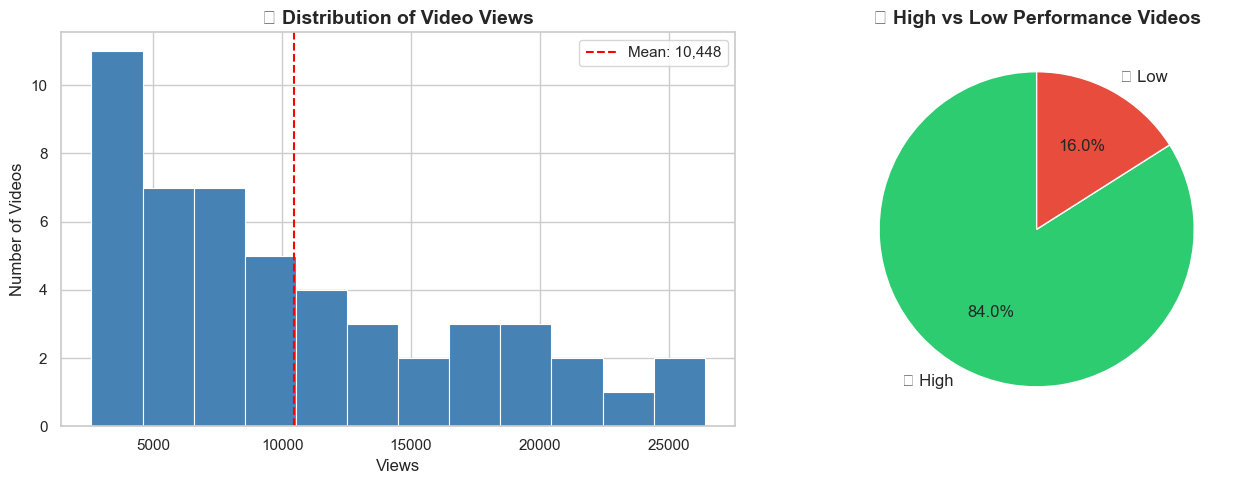

In [6]:
# ============================================================
# VISUALIZATION 1: Views Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of views
axes[0].hist(df['views'], bins=12, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].set_title('📊 Distribution of Video Views', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Number of Videos')
axes[0].axvline(df['views'].mean(), color='red', linestyle='--', label=f'Mean: {df["views"].mean():,.0f}')
axes[0].legend()

# Pie chart of performance
perf_counts = df['performance_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(perf_counts, labels=perf_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('🏆 High vs Low Performance Videos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

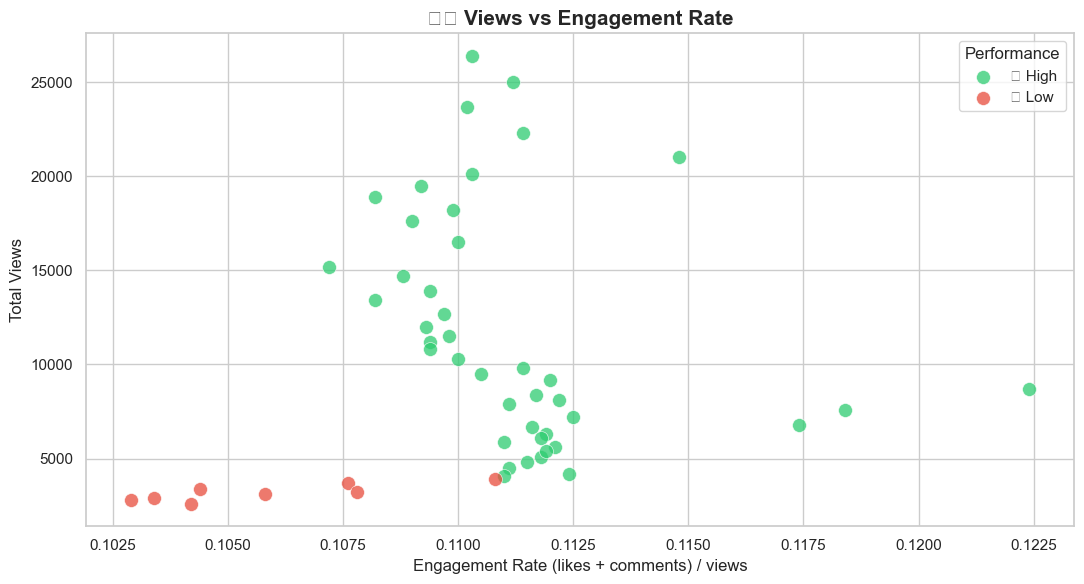

💡 Insight: High-performing videos tend to cluster at higher view counts.


In [7]:
# ============================================================
# VISUALIZATION 2: Views vs Engagement Rate (Scatter Plot)
# ============================================================
plt.figure(figsize=(11, 6))

# Color points by performance label
colors_map = {'⭐ High': '#2ecc71', '📉 Low': '#e74c3c'}
for label, group in df.groupby('performance_label'):
    plt.scatter(
        group['engagement_rate'],
        group['views'],
        label=label,
        color=colors_map[label],
        s=100, alpha=0.75, edgecolors='white', linewidth=0.5
    )

plt.title('👁️ Views vs Engagement Rate', fontsize=15, fontweight='bold')
plt.xlabel('Engagement Rate (likes + comments) / views', fontsize=12)
plt.ylabel('Total Views', fontsize=12)
plt.legend(title='Performance', fontsize=11)
plt.tight_layout()
plt.show()

print("💡 Insight: High-performing videos tend to cluster at higher view counts.")

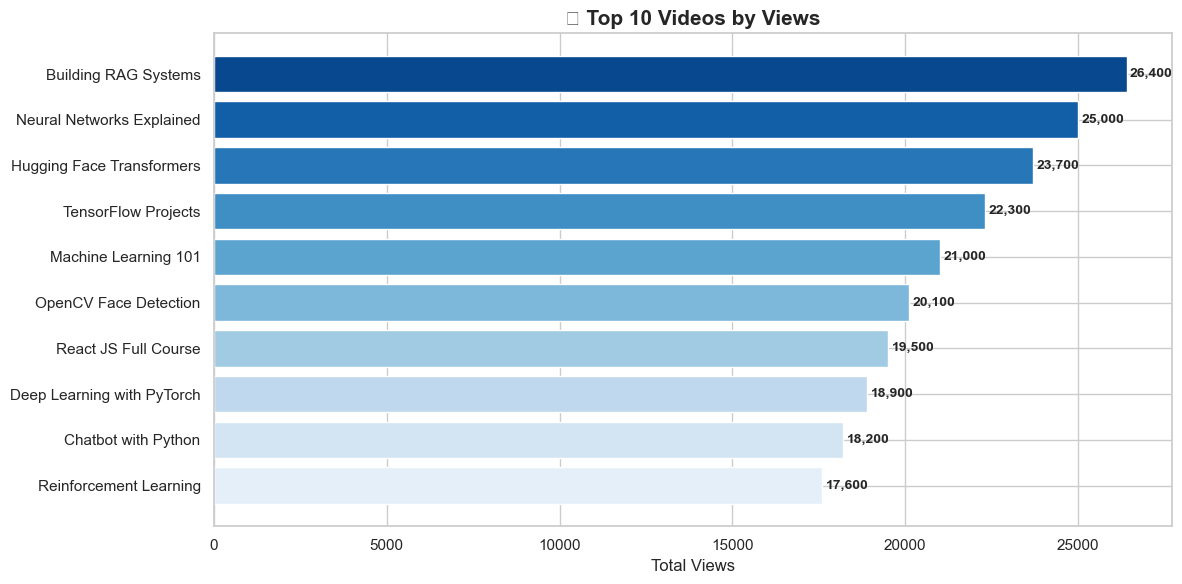

In [8]:
# ============================================================
# VISUALIZATION 3: Top 10 Performing Videos
# ============================================================
top10 = df.nlargest(10, 'views')[['title', 'views']].reset_index(drop=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['title'], top10['views'], color=sns.color_palette('Blues_r', 10))

# Add value labels on bars
for bar, val in zip(bars, top10['views']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.title('🏆 Top 10 Videos by Views', fontsize=15, fontweight='bold')
plt.xlabel('Total Views', fontsize=12)
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()
plt.show()

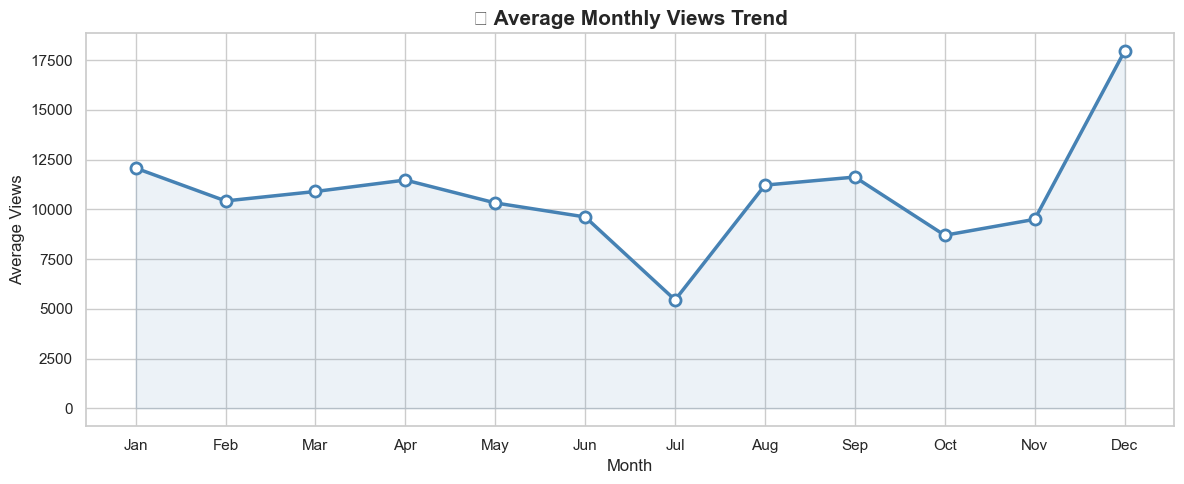

In [9]:
# ============================================================
# VISUALIZATION 4: Monthly Views Trend
# ============================================================
monthly = df.groupby('month')['views'].mean().reset_index()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly['month_name'] = monthly['month'].map(month_names)

plt.figure(figsize=(12, 5))
plt.plot(monthly['month_name'], monthly['views'], marker='o', linewidth=2.5,
         color='steelblue', markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.fill_between(range(len(monthly)), monthly['views'], alpha=0.1, color='steelblue')
plt.title('📅 Average Monthly Views Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(range(len(monthly)), monthly['month_name'])
plt.tight_layout()
plt.show()

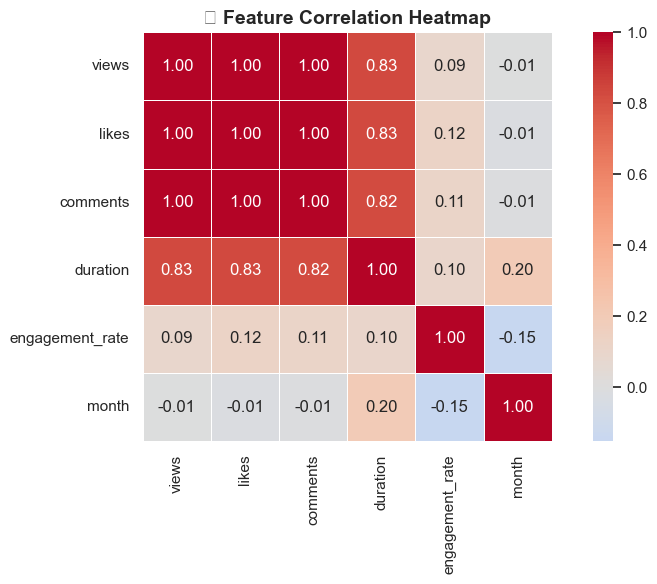

💡 Key: Values close to 1.0 = strong positive correlation, -1.0 = strong negative


In [10]:
# ============================================================
# VISUALIZATION 5: Correlation Heatmap
# ============================================================
# Shows how features are related to each other
numeric_cols = ['views', 'likes', 'comments', 'duration', 'engagement_rate', 'month']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('🔗 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Key: Values close to 1.0 = strong positive correlation, -1.0 = strong negative")

## Step 6: Prepare Data for Machine Learning

In [11]:
# --- Define Features (X) and Targets (y) ---
# Features are the columns the model uses to make predictions
FEATURE_COLS = ['likes', 'comments', 'duration', 'engagement_rate', 'day', 'month', 'weekday']

X = df[FEATURE_COLS]                 # Input features
y_views = df['views']                # Target for Regression (predict views)
y_perf  = df['performance']          # Target for Classification (predict High/Low)

# --- Split into Training and Testing Sets ---
# 80% for training, 20% for testing (with random_state for reproducibility)
X_train, X_test, yv_train, yv_test = train_test_split(
    X, y_views, test_size=0.2, random_state=42
)
_, _, yp_train, yp_test = train_test_split(
    X, y_perf, test_size=0.2, random_state=42
)

print(f"✅ Data split complete!")
print(f"   🏋️  Training set: {X_train.shape[0]} videos")
print(f"   🧪  Testing set : {X_test.shape[0]} videos")
print(f"   📌  Features used: {FEATURE_COLS}")

✅ Data split complete!
   🏋️  Training set: 40 videos
   🧪  Testing set : 10 videos
   📌  Features used: ['likes', 'comments', 'duration', 'engagement_rate', 'day', 'month', 'weekday']


## Step 7: Machine Learning — Regression (Predict Views)

In [12]:
# ============================================================
# LINEAR REGRESSION — Predict exact view count
# ============================================================

# Create the model
reg_model = LinearRegression()

# Train it on our training data
reg_model.fit(X_train, yv_train)

# Make predictions on the test data
yv_pred = reg_model.predict(X_test)

# Clip negatives (views can't be negative)
yv_pred = np.clip(yv_pred, 0, None)

# --- Evaluate the model ---
mae = mean_absolute_error(yv_test, yv_pred)
r2  = r2_score(yv_test, yv_pred)

print("📈 LINEAR REGRESSION — View Count Predictor")
print("=" * 45)
print(f"   Mean Absolute Error (MAE): {mae:,.0f} views")
print(f"   R² Score               : {r2:.3f}  (1.0 = perfect)")
print()

# Show comparison table
comparison = pd.DataFrame({
    'Actual Views': yv_test.values,
    'Predicted Views': yv_pred.astype(int)
}).reset_index(drop=True)
comparison['Difference'] = abs(comparison['Actual Views'] - comparison['Predicted Views'])
print("📋 Actual vs Predicted (Test Set):")
print(comparison.to_string(index=False))

📈 LINEAR REGRESSION — View Count Predictor
   Mean Absolute Error (MAE): 90 views
   R² Score               : 0.999  (1.0 = perfect)

📋 Actual vs Predicted (Test Set):
 Actual Views  Predicted Views  Difference
        18900            18502         398
         6700             6668          32
         9800             9899          99
         2600             2754         154
         6300             6248          52
         9500             9499           1
         8400             8387          13
        12000            12006           6
         5400             5445          45
         4800             4900         100


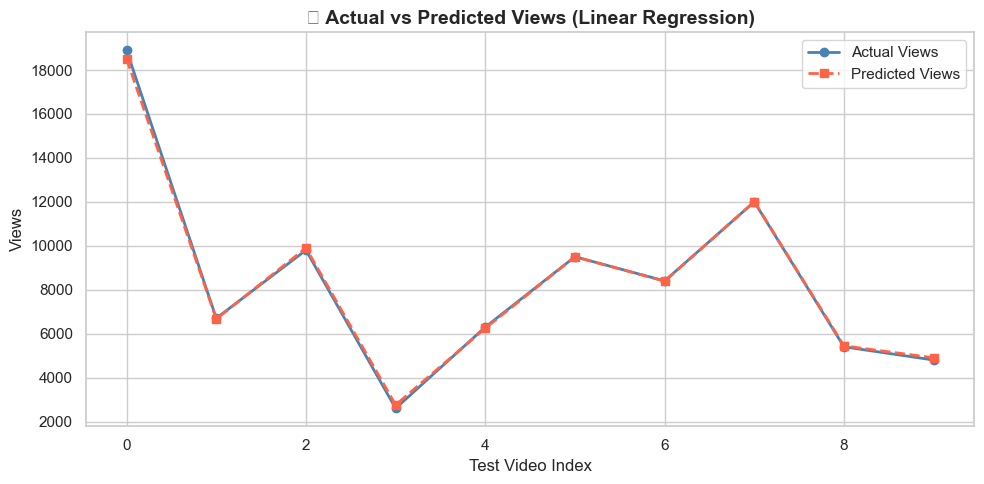

In [13]:
# ============================================================
# VISUALIZATION: Actual vs Predicted Views
# ============================================================
plt.figure(figsize=(10, 5))

x_axis = range(len(yv_test))
plt.plot(x_axis, yv_test.values, 'o-', label='Actual Views', color='steelblue', linewidth=2)
plt.plot(x_axis, yv_pred.astype(int), 's--', label='Predicted Views', color='tomato', linewidth=2)

plt.title('📈 Actual vs Predicted Views (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Test Video Index')
plt.ylabel('Views')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Step 8: Machine Learning — Classification (High/Low Performance)

In [14]:
# ============================================================
# RANDOM FOREST CLASSIFIER — Predict High/Low performance
# ============================================================

# Create the model (100 decision trees in the forest)
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train it
clf_model.fit(X_train, yp_train)

# Predict on test data
yp_pred = clf_model.predict(X_test)

# --- Evaluate ---
accuracy = accuracy_score(yp_test, yp_pred)

print("🌳 RANDOM FOREST — Performance Classifier")
print("=" * 45)
print(f"   Accuracy: {accuracy * 100:.1f}%")
print()
print("📋 Detailed Classification Report:")
print(classification_report(yp_test, yp_pred, target_names=['Low (0)', 'High (1)']))

🌳 RANDOM FOREST — Performance Classifier
   Accuracy: 100.0%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00         1
    High (1)       1.00      1.00      1.00         9

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



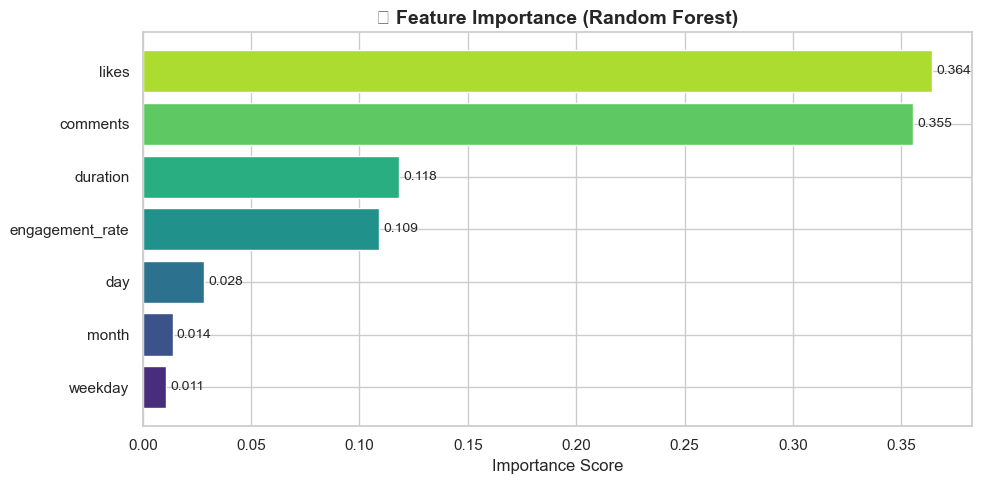

💡 The higher the bar, the more influential that feature is in predicting performance.


In [15]:
# ============================================================
# VISUALIZATION: Feature Importance from Random Forest
# ============================================================
importances = clf_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(feat_imp.index, feat_imp.values,
                color=sns.color_palette('viridis', len(feat_imp)))

for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('🌳 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("💡 The higher the bar, the more influential that feature is in predicting performance.")

## Step 9: Machine Learning — Clustering (Group Videos)

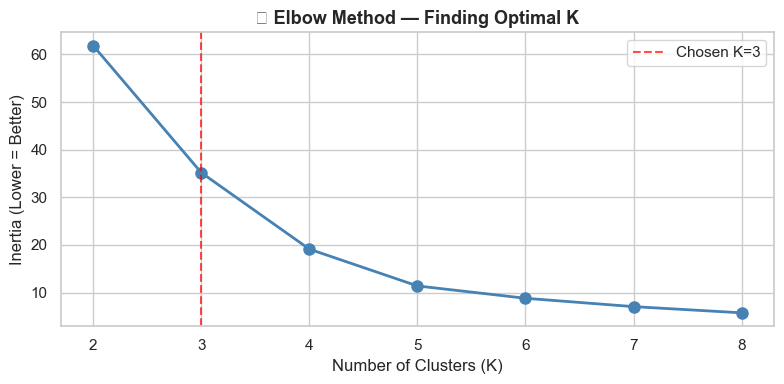

💡 We choose K=3 because the 'elbow' bend appears around 3 clusters.


In [16]:
# ============================================================
# KMEANS CLUSTERING — Group videos into similar clusters
# ============================================================

# Use only 2 features for easy visualization
cluster_features = ['views', 'engagement_rate']
X_cluster = df[cluster_features].copy()

# Scale the features (important for KMeans!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# --- Find optimal K using the Elbow Method ---
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.title('📐 Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Lower = Better)')
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Chosen K=3')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 We choose K=3 because the 'elbow' bend appears around 3 clusters.")

✅ KMeans clustering complete!

📊 Cluster Summary:
                  views  engagement_rate    likes
cluster_label                                    
🔵 Low Reach     3100.00             0.11   280.00
🟡 Mid Reach     7292.31             0.11   705.19
🟢 High Reach   18300.00             0.11  1741.76


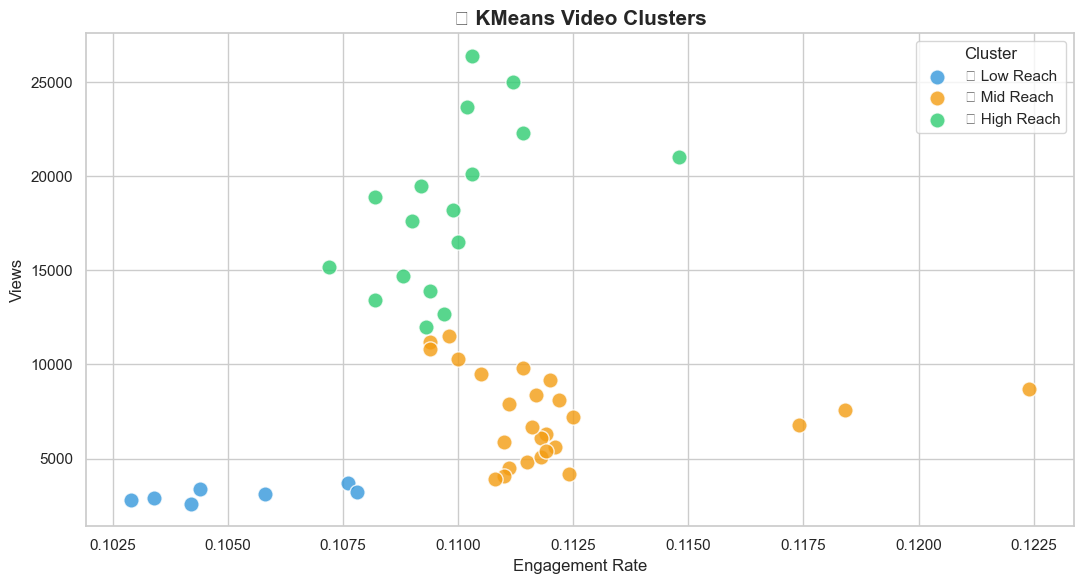

In [17]:
# --- Apply KMeans with K=3 ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Label the clusters meaningfully based on average views
cluster_means = df.groupby('cluster')['views'].mean().sort_values()
cluster_label_map = {
    cluster_means.index[0]: '🔵 Low Reach',
    cluster_means.index[1]: '🟡 Mid Reach',
    cluster_means.index[2]: '🟢 High Reach'
}
df['cluster_label'] = df['cluster'].map(cluster_label_map)

print("✅ KMeans clustering complete!")
print("\n📊 Cluster Summary:")
summary = df.groupby('cluster_label')[['views', 'engagement_rate', 'likes']].mean().round(2)
print(summary.to_string())

# --- Plot the clusters ---
plt.figure(figsize=(11, 6))
colors_c = {'🔵 Low Reach': '#3498db', '🟡 Mid Reach': '#f39c12', '🟢 High Reach': '#2ecc71'}

for label, group in df.groupby('cluster_label'):
    plt.scatter(group['engagement_rate'], group['views'],
                label=label, color=colors_c[label], s=120, alpha=0.8, edgecolors='white')

plt.title('🔵 KMeans Video Clusters', fontsize=15, fontweight='bold')
plt.xlabel('Engagement Rate', fontsize=12)
plt.ylabel('Views', fontsize=12)
plt.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.show()

## Step 10: 🔮 Prediction Section — Predict Your Own Video!

Enter your video's details below and the system will predict:
- 📊 Estimated view count
- 🏷️ Whether it will be High or Low performance

In [18]:
# ============================================================
# 🔮 PREDICTION FUNCTION
# Modify the values below to test different scenarios!
# ============================================================

def predict_video(likes, comments, duration=15, day=15, month=6, weekday=2):
    """
    Predict views and performance for a video.
    
    Parameters:
    -----------
    likes    : int   - Number of likes on the video
    comments : int   - Number of comments
    duration : int   - Video duration in minutes (default: 15)
    day      : int   - Day of month it was published (default: 15)
    month    : int   - Month it was published (default: 6 = June)
    weekday  : int   - 0=Mon, 1=Tue, 2=Wed ... 6=Sun (default: 2 = Wed)
    """
    # Estimate engagement rate (assume views are ~10x likes for estimation)
    est_views = likes * 10  # rough estimate
    engagement_rate = (likes + comments) / max(est_views, 1)
    
    # Build input array in the same feature order as training
    input_data = pd.DataFrame([[
        likes, comments, duration, engagement_rate, day, month, weekday
    ]], columns=FEATURE_COLS)
    
    # --- Predict Views (Regression) ---
    pred_views = int(max(0, reg_model.predict(input_data)[0]))
    
    # --- Predict Performance (Classification) ---
    pred_perf = clf_model.predict(input_data)[0]
    pred_prob = clf_model.predict_proba(input_data)[0]
    confidence = max(pred_prob) * 100
    
    perf_label = '⭐ HIGH Performance' if pred_perf == 1 else '📉 LOW Performance'
    
    # --- Display Results ---
    print("=" * 50)
    print("   🔮 VIDEO PREDICTION RESULTS")
    print("=" * 50)
    print(f"   Input Data:")
    print(f"   ├── Likes      : {likes:,}")
    print(f"   ├── Comments   : {comments:,}")
    print(f"   ├── Duration   : {duration} min")
    print(f"   └── Published  : Month={month}, Day={day}, Weekday={weekday}")
    print()
    print(f"   📊 Predicted Views      : {pred_views:,} views")
    print(f"   🏷️  Predicted Performance: {perf_label}")
    print(f"   🎯 Confidence           : {confidence:.1f}%")
    print("=" * 50)
    
    return pred_views, pred_perf


# ============================================================
# ✏️  CHANGE THESE VALUES TO TEST YOUR OWN VIDEO!
# ============================================================
YOUR_LIKES    = 850    # How many likes your video has
YOUR_COMMENTS = 130    # How many comments
YOUR_DURATION = 20     # Video length in minutes
YOUR_MONTH    = 9      # Month published (1-12)
YOUR_DAY      = 10     # Day published (1-31)
YOUR_WEEKDAY  = 5      # 0=Mon ... 6=Sun

# Run the prediction
predict_video(
    likes    = YOUR_LIKES,
    comments = YOUR_COMMENTS,
    duration = YOUR_DURATION,
    month    = YOUR_MONTH,
    day      = YOUR_DAY,
    weekday  = YOUR_WEEKDAY
)

   🔮 VIDEO PREDICTION RESULTS
   Input Data:
   ├── Likes      : 850
   ├── Comments   : 130
   ├── Duration   : 20 min
   └── Published  : Month=9, Day=10, Weekday=5

   📊 Predicted Views      : 8,494 views
   🏷️  Predicted Performance: ⭐ HIGH Performance
   🎯 Confidence           : 100.0%


(8494, np.int64(1))

In [19]:
# ============================================================
# Test Multiple Scenarios at Once
# ============================================================
scenarios = [
    {"name": "Viral Tutorial",     "likes": 2500, "comments": 420, "duration": 30},
    {"name": "Average How-To",     "likes": 600,  "comments": 80,  "duration": 15},
    {"name": "Short Clip",         "likes": 150,  "comments": 20,  "duration": 5},
    {"name": "Deep Dive Course",   "likes": 1800, "comments": 290, "duration": 60},
]

print("\n📊 BATCH SCENARIO PREDICTIONS")
print("=" * 70)
print(f"{'Scenario':<22} {'Likes':>7} {'Comments':>10} {'Pred Views':>12} {'Performance':>18}")
print("-" * 70)

for s in scenarios:
    eng = (s['likes'] + s['comments']) / max(s['likes'] * 10, 1)
    inp = pd.DataFrame([[s['likes'], s['comments'], s['duration'], eng, 15, 6, 2]],
                       columns=FEATURE_COLS)
    v = int(max(0, reg_model.predict(inp)[0]))
    p = clf_model.predict(inp)[0]
    label = '⭐ HIGH' if p == 1 else '📉 LOW'
    print(f"{s['name']:<22} {s['likes']:>7,} {s['comments']:>10,} {v:>12,} {label:>18}")

print("=" * 70)


📊 BATCH SCENARIO PREDICTIONS
Scenario                 Likes   Comments   Pred Views        Performance
----------------------------------------------------------------------
Viral Tutorial           2,500        420       26,671             ⭐ HIGH
Average How-To             600         80        5,923             ⭐ HIGH
Short Clip                 150         20        1,390              📉 LOW
Deep Dive Course         1,800        290       19,294             ⭐ HIGH


## Step 11: Final Summary Dashboard

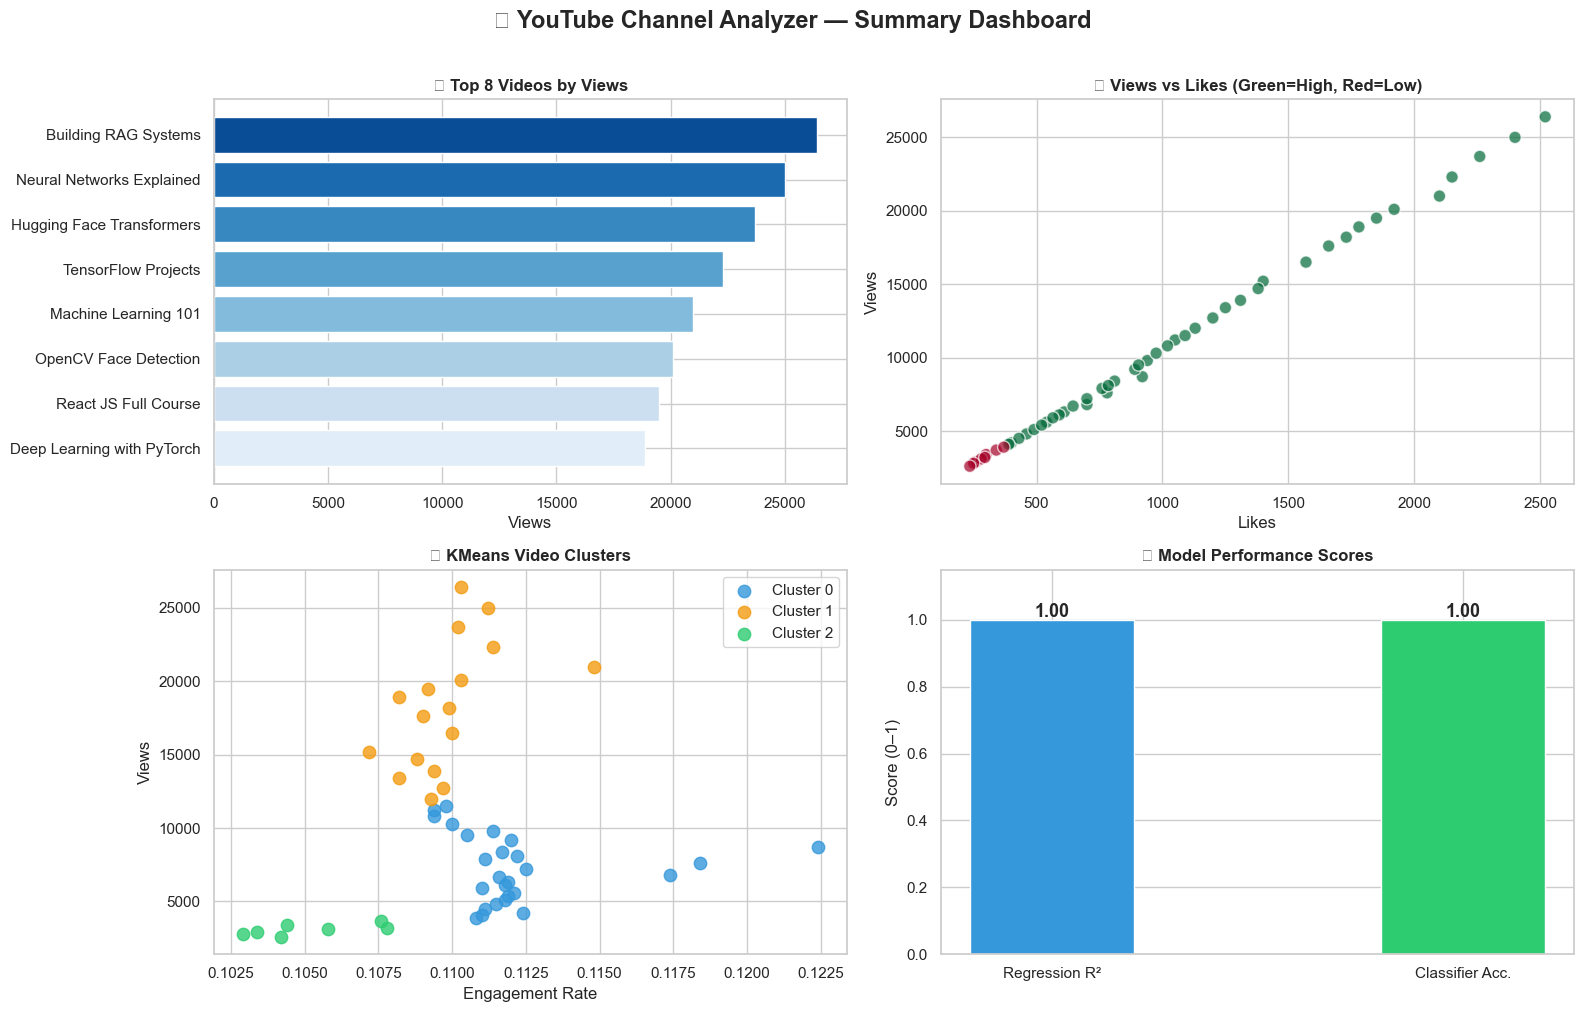

In [20]:
# ============================================================
# FINAL SUMMARY DASHBOARD
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📺 YouTube Channel Analyzer — Summary Dashboard', fontsize=17, fontweight='bold', y=1.01)

# --- Plot 1: Top 8 Videos ---
top8 = df.nlargest(8, 'views')
axes[0,0].barh(top8['title'], top8['views'], color=sns.color_palette('Blues_r', 8))
axes[0,0].set_title('🏆 Top 8 Videos by Views', fontweight='bold')
axes[0,0].invert_yaxis()
axes[0,0].set_xlabel('Views')

# --- Plot 2: Scatter Views vs Likes ---
axes[0,1].scatter(df['likes'], df['views'], c=df['performance'],
                  cmap='RdYlGn', s=80, alpha=0.7, edgecolors='white')
axes[0,1].set_title('💚 Views vs Likes (Green=High, Red=Low)', fontweight='bold')
axes[0,1].set_xlabel('Likes')
axes[0,1].set_ylabel('Views')

# --- Plot 3: Clusters ---
colors_c2 = ['#3498db', '#f39c12', '#2ecc71']
for i, (label, group) in enumerate(df.groupby('cluster')):
    axes[1,0].scatter(group['engagement_rate'], group['views'],
                      color=colors_c2[i], label=f'Cluster {i}', s=80, alpha=0.8)
axes[1,0].set_title('🔵 KMeans Video Clusters', fontweight='bold')
axes[1,0].set_xlabel('Engagement Rate')
axes[1,0].set_ylabel('Views')
axes[1,0].legend()

# --- Plot 4: Model accuracy bars ---
metrics = ['Regression R²', 'Classifier Acc.']
scores  = [r2_score(yv_test, yv_pred), accuracy_score(yp_test, yp_pred)]
bar_colors = ['#3498db', '#2ecc71']
bars4 = axes[1,1].bar(metrics, scores, color=bar_colors, width=0.4)
for bar, val in zip(bars4, scores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}', ha='center', fontweight='bold', fontsize=13)
axes[1,1].set_ylim(0, 1.15)
axes[1,1].set_title('🎯 Model Performance Scores', fontweight='bold')
axes[1,1].set_ylabel('Score (0–1)')

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================
print("\n" + "="*55)
print("  📺 YouTube Channel Analyzer — Project Summary")
print("="*55)
print(f"  📁 Total Videos Analyzed    : {len(df)}")
print(f"  ⭐ High-Performance Videos  : {df['performance'].sum()} ({df['performance'].mean()*100:.0f}%)")
print(f"  📉 Low-Performance Videos   : {(df['performance']==0).sum()}")
print(f"  👁️  Average Views            : {df['views'].mean():,.0f}")
print(f"  🔥 Highest Views            : {df['views'].max():,} ({df.loc[df['views'].idxmax(), 'title']})")
print()
print("  🤖 Machine Learning Results:")
print(f"  ├── Linear Regression R²     : {r2_score(yv_test, yv_pred):.3f}")
print(f"  ├── Regression MAE           : {mean_absolute_error(yv_test, yv_pred):,.0f} views")
print(f"  ├── Random Forest Accuracy   : {accuracy_score(yp_test, yp_pred)*100:.1f}%")
print(f"  └── KMeans Clusters          : 3 groups (Low / Mid / High Reach)")
print()
print("  ✅ Project completed successfully!")
print("="*55)


  📺 YouTube Channel Analyzer — Project Summary
  📁 Total Videos Analyzed    : 50
  ⭐ High-Performance Videos  : 42 (84%)
  📉 Low-Performance Videos   : 8
  👁️  Average Views            : 10,448
  🔥 Highest Views            : 26,400 (Building RAG Systems)

  🤖 Machine Learning Results:
  ├── Linear Regression R²     : 0.999
  ├── Regression MAE           : 90 views
  ├── Random Forest Accuracy   : 100.0%
  └── KMeans Clusters          : 3 groups (Low / Mid / High Reach)

  ✅ Project completed successfully!
